## Implementación del Algoritmo SVM (Support Vector Machine)

Se utiliza la librearia sklearn y se carga el dataset Iris dataset que contiene diferentes especies de la flor iris, despues se utiliza el algortimo SVM (Máquina de Vectores de Soporte) para clasificar las diferentes especies.

Del dataset se utilizan 105 muestras para entrenamiento y 45 como conjunto de prueba.



In [1]:
# Importar las librerías necesarias
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Cargar un dataset de ejemplo (Iris dataset)
iris = datasets.load_iris()
X = iris.data  # Características
y = iris.target # Etiquetas de clase

print("Dimensiones del dataset de características (X):", X.shape)
print("Dimensiones del dataset de etiquetas (y):", y.shape)
print("Primeras 5 filas de X:\n", X[:5])
print("Primeras 5 etiquetas de y:\n", y[:5])


Dimensiones del dataset de características (X): (150, 4)
Dimensiones del dataset de etiquetas (y): (150,)
Primeras 5 filas de X:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Primeras 5 etiquetas de y:
 [0 0 0 0 0]


In [2]:
# Dividir los datos en conjuntos de entrenamiento y prueba
# train_size=0.7 significa 70% para entrenamiento y 30% para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Dimensiones del conjunto de entrenamiento (X_train):", X_train.shape)
print("Dimensiones del conjunto de prueba (X_test):", X_test.shape)


Dimensiones del conjunto de entrenamiento (X_train): (105, 4)
Dimensiones del conjunto de prueba (X_test): (45, 4)


In [3]:
# Crear una instancia del clasificador SVM (Support Vector Classifier)
# Usamos un kernel lineal para este ejemplo simple
svm_model = SVC(kernel='linear', random_state=42)

# Entrenar el modelo con los datos de entrenamiento
svm_model.fit(X_train, y_train)

print("Modelo SVM entrenado exitosamente.")


Modelo SVM entrenado exitosamente.


In [4]:
# Realizar predicciones sobre el conjunto de prueba
y_pred = svm_model.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Precisión del modelo SVM: {accuracy:.2f}")
print("\nReporte de Clasificación:\n")
print(report)

# Ejemplo de predicción para una nueva muestra (inventada)
# Las 4 características del dataset Iris son: longitud de sépalo, ancho de sépalo, longitud de pétalo, ancho de pétalo
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]]) # Una flor Iris Setosa típica
predicted_class = svm_model.predict(new_sample)

print(f"\nPredicción para una nueva muestra {new_sample[0]}: Clase {predicted_class[0]} ({iris.target_names[predicted_class[0]]})")


Precisión del modelo SVM: 1.00

Reporte de Clasificación:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Predicción para una nueva muestra [5.1 3.5 1.4 0.2]: Clase 0 (setosa)


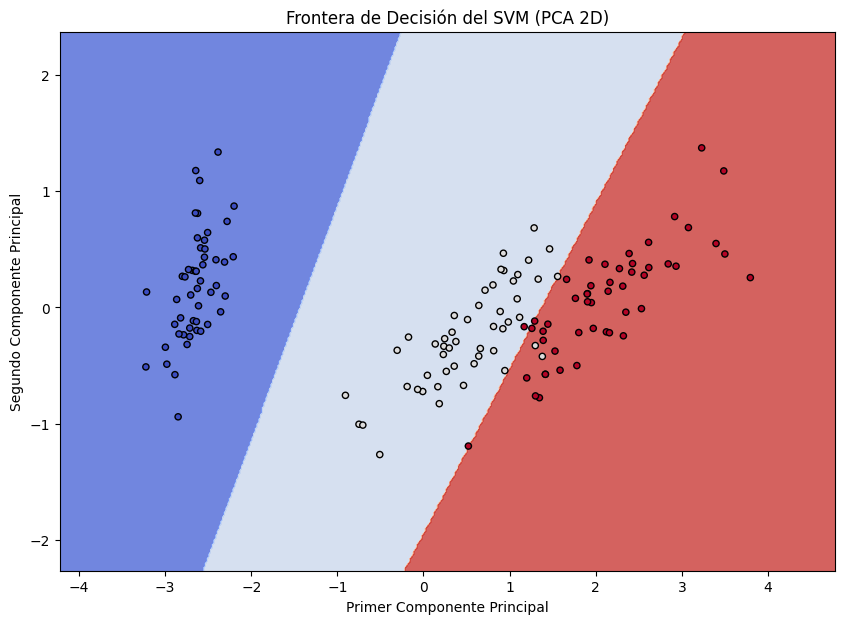

In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reducir la dimensionalidad a 2 componentes principales para visualización
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

# Dividir los datos reducidos en conjuntos de entrenamiento y prueba
X_train_reduced, X_test_reduced, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=42)

# Entrenar un nuevo modelo SVM con los datos reducidos
svm_model_2d = SVC(kernel='linear', random_state=42)
svm_model_2d.fit(X_train_reduced, y_train)

# Crear una malla para graficar la frontera de decisión
x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predecir las clases para cada punto de la malla
Z = svm_model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar la frontera de decisión y los puntos de datos
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
plt.xlabel('Primer Componente Principal')
plt.ylabel('Segundo Componente Principal')
plt.title('Frontera de Decisión del SVM (PCA 2D)')
plt.show()
